In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

n = 100000

data = {
    "Customer_ID": range(1, n + 1),
    "Age": np.random.randint(18, 71, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(0, 11, n),
    "Balance": np.random.randint(0, 200001, n),
    "CreditScore": np.random.randint(300, 901, n),
    "EstimatedSalary": np.random.randint(10000, 150001, n),
    "NumOfProducts": np.random.randint(1, 5, n),
    "IsActiveMember": np.random.choice(["Yes", "No"], n)
}

df = pd.DataFrame(data)
df.head()

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember
0,1,56,Female,3,138803,718,121992,4,No
1,2,69,Male,1,174102,534,125877,2,No
2,3,46,Female,10,90135,653,39062,2,Yes
3,4,32,Male,6,160284,787,66364,2,Yes
4,5,60,Female,6,24298,681,116045,2,Yes


In [3]:
def generate_churn(row):
    if (row["Balance"] > 150000 and row["IsActiveMember"] == "No") or \
       (row["CreditScore"] < 400) or \
       (row["NumOfProducts"] == 1 and row["Tenure"] < 2):
        return 1
    else:
        return 0

df["Churn"] = df.apply(generate_churn, axis=1)

df.head()

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Churn
0,1,56,Female,3,138803,718,121992,4,No,0
1,2,69,Male,1,174102,534,125877,2,No,1
2,3,46,Female,10,90135,653,39062,2,Yes,0
3,4,32,Male,6,160284,787,66364,2,Yes,0
4,5,60,Female,6,24298,681,116045,2,Yes,0


In [4]:
print("Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Missing Values:
 Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64

Data Types:
 Customer_ID         int64
Age                 int64
Gender             object
Tenure              int64
Balance             int64
CreditScore         int64
EstimatedSalary     int64
NumOfProducts       int64
IsActiveMember     object
Churn               int64
dtype: object


In [5]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["IsActiveMember"] = df["IsActiveMember"].map({"Yes": 1, "No": 0})

In [6]:
df.describe()

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Churn
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,50000.500000,43.984060,0.498910,4.988760,99742.233670,599.942750,79959.021360,2.501980,0.498930,0.30303
std,28867.657797,15.251827,0.500001,3.163744,57670.541911,173.269555,40445.277417,1.117734,0.500001,0.45957
min,1.000000,18.000000,0.000000,0.000000,0.000000,300.000000,10000.000000,1.000000,0.000000,0.00000
25%,25000.750000,31.000000,0.000000,2.000000,49819.000000,450.000000,45009.000000,2.000000,0.000000,0.00000
50%,50000.500000,44.000000,0.000000,5.000000,99729.000000,599.000000,80008.500000,3.000000,0.000000,0.00000
75%,75000.250000,57.000000,1.000000,8.000000,149691.250000,750.000000,114916.000000,4.000000,1.000000,1.00000
max,100000.000000,70.000000,1.000000,10.000000,200000.000000,900.000000,150000.000000,4.000000,1.000000,1.00000


In [7]:
print(df["Churn"].value_counts())

Churn
0    69697
1    30303
Name: count, dtype: int64


In [8]:
# Age groups
df["Age_Group"] = pd.cut(df["Age"],
                        bins=[18, 30, 45, 60, 70],
                        labels=["18-30", "31-45", "46-60", "61-70"])

print("\nAge Group vs Churn:\n", pd.crosstab(df["Age_Group"], df["Churn"]))

print("\nGender vs Churn:\n", pd.crosstab(df["Gender"], df["Churn"]))

print("\nActive Member vs Churn:\n", pd.crosstab(df["IsActiveMember"], df["Churn"]))

print("\nProducts vs Churn:\n", pd.crosstab(df["NumOfProducts"], df["Churn"]))


Age Group vs Churn:
 Churn          0     1
Age_Group             
18-30      15747  6780
31-45      19932  8740
46-60      19694  8488
61-70      13052  5751

Gender vs Churn:
 Churn       0      1
Gender              
0       35015  15094
1       34682  15209

Active Member vs Churn:
 Churn               0      1
IsActiveMember              
0               30037  20070
1               39660  10233

Products vs Churn:
 Churn              0      1
NumOfProducts              
1              14863  10074
2              18236   6721
3              18406   6671
4              18192   6837


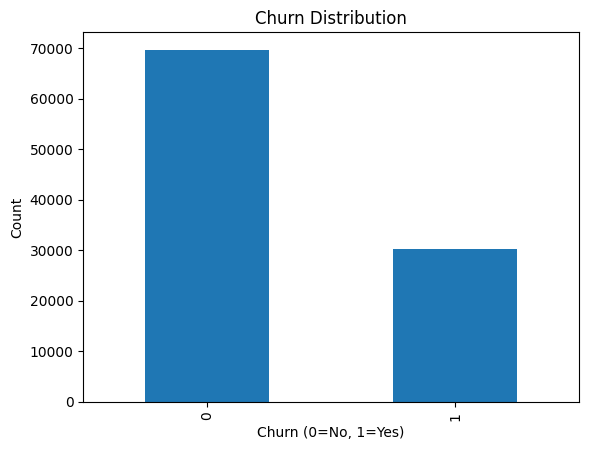

In [9]:
df["Churn"].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

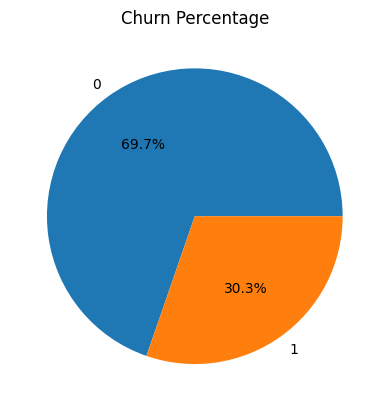

In [10]:
df["Churn"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

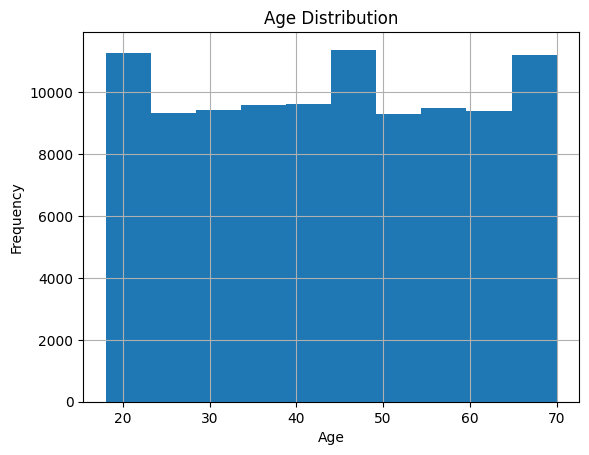

In [11]:
df["Age"].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

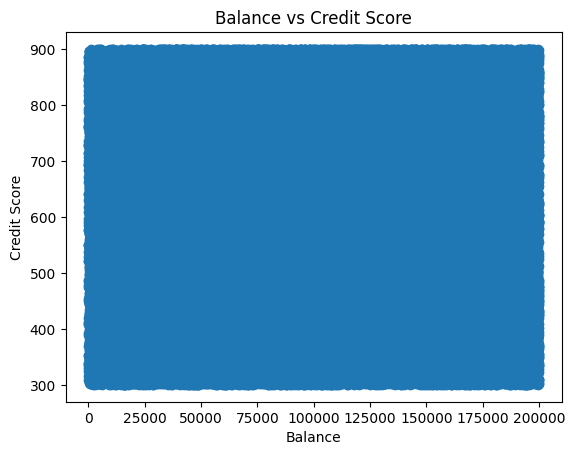

In [12]:
plt.scatter(df["Balance"], df["CreditScore"])
plt.title("Balance vs Credit Score")
plt.xlabel("Balance")
plt.ylabel("Credit Score")
plt.show()

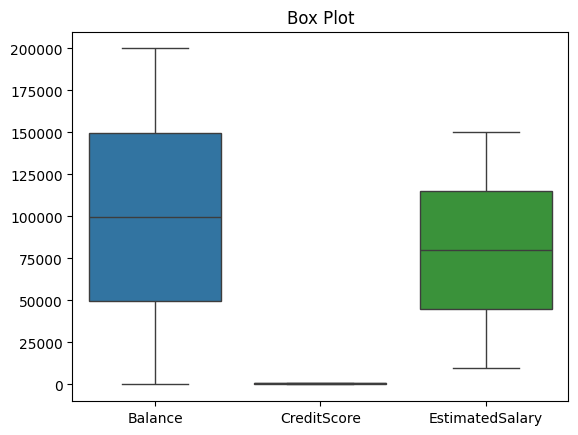

In [13]:
sns.boxplot(data=df[["Balance", "CreditScore", "EstimatedSalary"]])
plt.title("Box Plot")
plt.show()

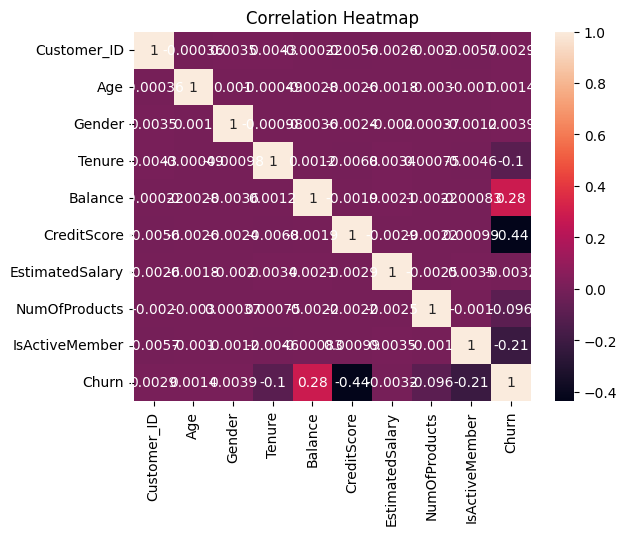

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
high_churn = df[df["Churn"] == 1]
print("High Churn Customers:", len(high_churn))

High Churn Customers: 30303


In [16]:
df.to_csv("synthetic_customer_churn_data.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!
